# **Feature Analysis**

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET = 'car_details'

df = pd.read_csv(f'../data/raw/{DATASET}.csv')

## **Missing Values**

---

In [3]:
total_cars = []

total_cars_df = pd.DataFrame({
    'Total Cars' : [len(df)]
})
display(total_cars_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~
missing_data = []

features = ['price', 'manufacturer', 'model', 'year', 'kilometers', 'fuel_type', 'kw', 'le', 'condition',
    'trunk_capacity', 'body_type', 'seats', 'color', 'engine_capacity', 'drive_type', 'transmission_type', 
    'number_of_gears', 'transmission_subtype'
]

for col in features:
    missing_count = df[col].isna().sum()
    missing_data.append({
        'Feature': col.replace('_', ' ').title(),
        'Missing Count': missing_count,
        'Missing %': f'{(missing_count/len(df))*100:.2f}%'
    })

missing_df = pd.DataFrame(missing_data)
display(missing_df.style.hide(axis='index'))

Total Cars
106447


Feature,Missing Count,Missing %
Price,1102,1.04%
Manufacturer,0,0.00%
Model,10,0.01%
Year,0,0.00%
Kilometers,1712,1.61%
Fuel Type,1478,1.39%
Kw,1782,1.67%
Le,1782,1.67%
Condition,0,0.00%
Trunk Capacity,14406,13.53%


## **Price Analysis**

---

### **Price Ranges**


Range,Count,%
0 - 100k,62,0.06
100k - 200k,443,0.42
200k - 300k,1021,0.96
300k - 500k,3225,3.03
500k - 1M,8315,7.81
1M - 2M,16469,15.47
2M - 3M,13387,12.58
3M - 5M,17722,16.65
5M - 10M,21324,20.03
10M - 20M,16061,15.09


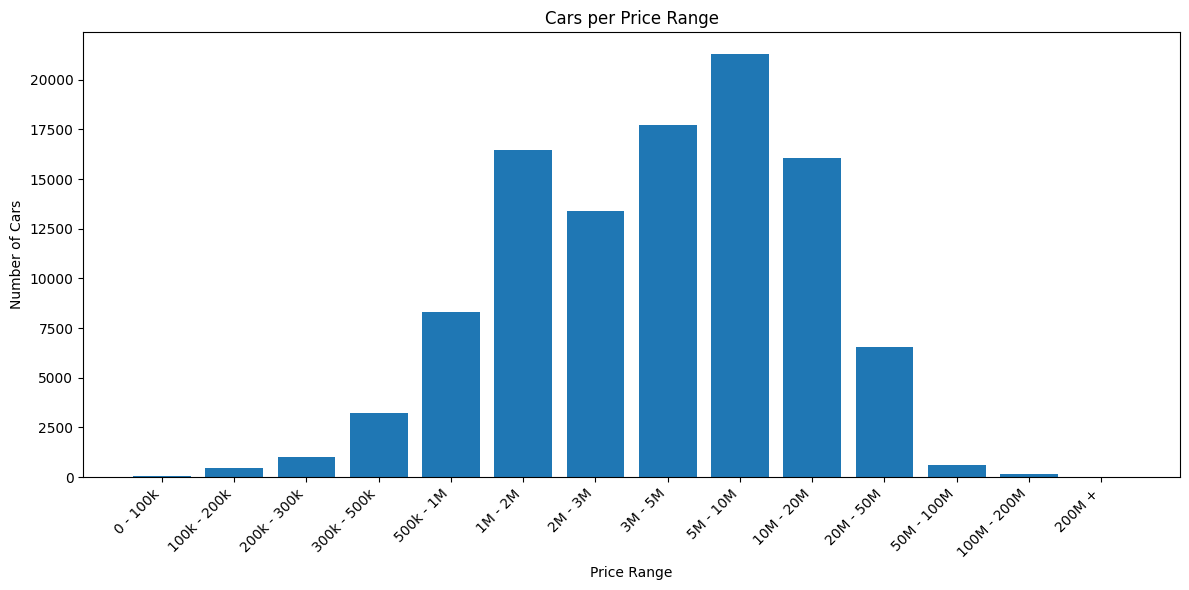

In [4]:
ranges = [
    (0, 100_000, "0 - 100k"),
    (100_000, 200_000, "100k - 200k"),
    (200_000, 300_000, "200k - 300k"),
    (300_000, 500_000, "300k - 500k"),
    (500_000, 1_000_000, "500k - 1M"),
    (1_000_000, 2_000_000, "1M - 2M"),
    (2_000_000, 3_000_000, "2M - 3M"),
    (3_000_000, 5_000_000, "3M - 5M"),
    (5_000_000, 10_000_000, "5M - 10M"),
    (10_000_000, 20_000_000, "10M - 20M"),
    (20_000_000, 50_000_000, "20M - 50M"),
    (50_000_000, 100_000_000, "50M - 100M"),
    (100_000_000, 200_000_000, "100M - 200M"),
    (200_000_000, float('inf'), "200M +")
]

data = []
for low, high, label in ranges:
    count = len(df[(df['price'] >= low) & (df['price'] < high)])
    percent = count / len(df) * 100
    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}'
    })

price_ranges_df = pd.DataFrame(data)
display(price_ranges_df.style.hide(axis='index'))



plt.figure(figsize=(12,6))
plt.bar(price_ranges_df['Range'], price_ranges_df['Count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Price Range")
plt.ylabel("Number of Cars")
plt.title("Cars per Price Range")
plt.tight_layout()
plt.show()

### **Outliers by Price & Most Expensive, Cheapest Car Exploration**


In [5]:
cars_under_200k_df = df[df['price'] <= 200_000].sort_values('price').head(30)
cars_over_100M_df = df[df['price'] >= 100_000_000].sort_values('price', ascending=False).head(30)

cars_under_200k_df = pd.DataFrame({
    'Price' : cars_under_200k_df['price'].values.astype(int),
    'Manufacturer' : cars_under_200k_df['manufacturer'].values,
    'Model' : cars_under_200k_df['model'].values,
    'Year' : cars_under_200k_df['year'].values,
    'kw' : cars_under_200k_df['kw'].values,

    '' : ' | ',
})

cars_over_100M_df = pd.DataFrame({
    '' : ' | ',
    'Price' : cars_over_100M_df['price'].values.astype(int),
    'Manufacturer' : cars_over_100M_df['manufacturer'].values,
    'Model' : cars_over_100M_df['model'].values,
    'Year' : cars_over_100M_df['year'].values,
    'kw' : cars_over_100M_df['kw'].values
})



combined = pd.concat(
    [cars_under_200k_df, cars_over_100M_df],
    axis=1
)
combined['Price'] = combined['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "kw"]:
    combined[col] = combined[col].map(lambda x: f"{x:.2f}") 


pd.set_option("display.max_rows", None)
display(combined.style.hide(axis="index"))


Price,Manufacturer,Model,Year,kw,,,Price,Manufacturer,Model,Year,kw
1,PEUGEOT,305,1984.00,57.00,|,|,1 230 191 104,MCLAREN,P1,2016.25,735.00
3,OPEL,VIVARO,2010.92,66.00,|,|,359 999 999,MERCEDES-MAYBACH,EGYÉB,2021.42,463.00
1 000,AUDI,A4,2019.33,140.00,|,|,355 775 000,MERCEDES-AMG,G-OSZTÁLY G 63,2015.83,400.00
3 850,BMW,Z SOROZAT Z4,2003.42,141.00,|,|,330 200 000,FERRARI,SF90 SPIDER,2022.58,574.00
25 000,MERCEDES-BENZ,GLE-OSZTÁLY GLE 250,2016.17,150.00,|,|,268 500 000,LAMBORGHINI,REVUELTO,2024.00,747.00
50 000,RENAULT,CLIO,1993.92,57.00,|,|,252 000 000,FERRARI,SF90 SPIDER,2024.75,574.00
55 000,SUZUKI,SWIFT,1997.25,50.00,|,|,249 900 000,FERRARI,SF90 SPIDER,2023.33,736.00
60 000,FORD,KA,2003.00,50.00,|,|,246 500 000,FERRARI,SF90 SPIDER,2025.00,nan
65 000,PEUGEOT,206,2004.42,66.00,|,|,234 300 000,MERCEDES-AMG,G-OSZTÁLY G 63,2025.00,588.00
65 000,FORD,ESCORT,1998.50,66.00,|,|,234 300 000,MERCEDES-BENZ,G-OSZTÁLY G 63 AMG,2025.00,588.00


### **Price Visualization with Log Transform**

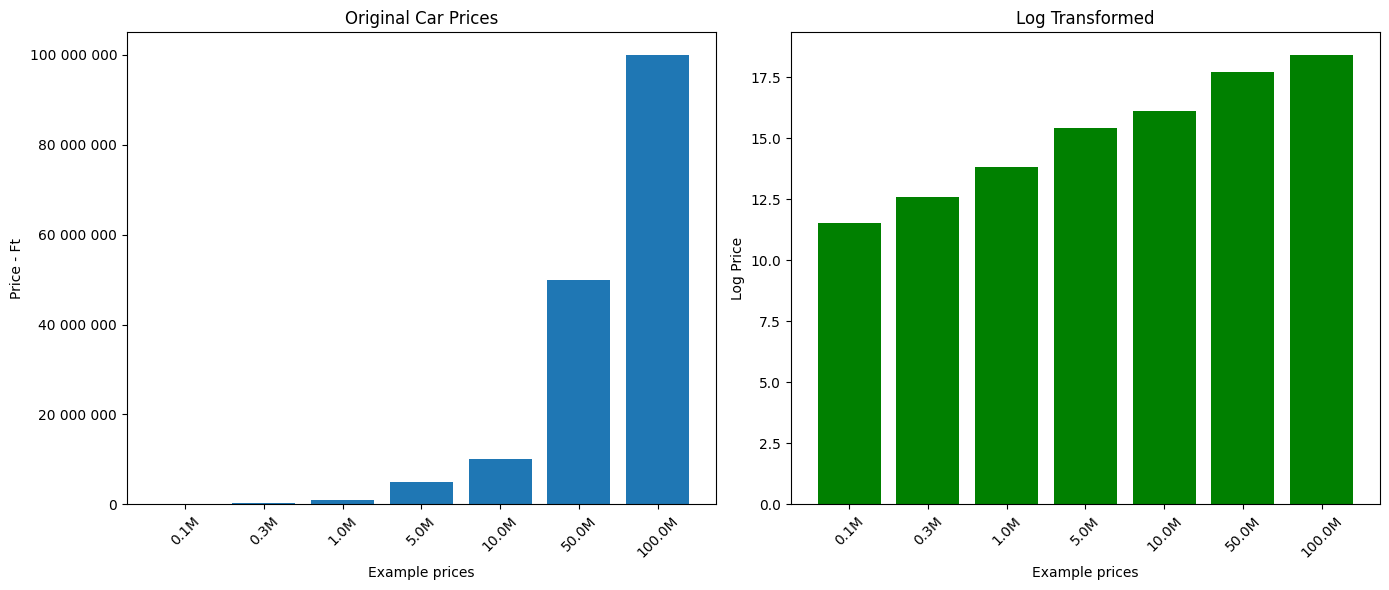

In [6]:
sample_prices = [100_000, 300_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, 100_000_000]
log_prices = np.log(sample_prices)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_title('Original Car Prices')
ax1.set_xlabel('Example prices')
ax1.set_ylabel('Price - Ft')
ax1.bar(range(len(sample_prices)), sample_prices)
ax1.set_xticks(range(len(sample_prices)))
ax1.set_xticklabels([f"{p/1_000_000:.1f}M" for p in sample_prices], rotation=45)
ax1.yaxis.set_major_formatter(lambda x, _: f"{int(x):,}".replace(",", " "))

# Log transformed
ax2.set_title('Log Transformed')
ax2.set_xlabel('Example prices')
ax2.set_ylabel('Log Price')
ax2.bar(range(len(log_prices)), log_prices, color='green')
ax2.set_xticks(range(len(log_prices)))
ax2.set_xticklabels([f"{p/1_000_000:.1f}M" for p in sample_prices], rotation=45)


plt.tight_layout()
plt.show()

## **Manufacturer & Model Analysis**

---

### **Unique Manufacturers & Their average prices**

In [7]:
manufacturer_unique_count = df['manufacturer'].nunique()
model_unique_count = df['model'].nunique()

manufacturer_unique_count_df = pd.DataFrame({
    'Unique Manufacturers' : [manufacturer_unique_count],
    'Unique Models' : [model_unique_count]
})
display(manufacturer_unique_count_df.style.hide(axis='index'))




manufacturer_unique_values = df['manufacturer'].value_counts()
manufacturer_avg_price = df.groupby('manufacturer')['price'].mean()
manufacturer_unique_models = df.groupby('manufacturer')['model'].nunique()

manufacturer_unique_df = pd.DataFrame({
    'Manufacturer': manufacturer_unique_values.index,
    'Car Count': manufacturer_unique_values.values,
    '%': (manufacturer_unique_values.values / len(df) * 100).round(2),
    'Unique Models': manufacturer_unique_models[manufacturer_unique_values.index].values,
    'Avg Price (M Ft)': (manufacturer_avg_price[manufacturer_unique_values.index] / 1e6).round(2)
})

pd.set_option("display.max_rows", None)
display(manufacturer_unique_df)

Unique Manufacturers,Unique Models
155,1745


,Manufacturer,Car Count,%,Unique Models,Avg Price (M Ft)
manufacturer,,,,,
VOLKSWAGEN,VOLKSWAGEN,9628,9.04,91,5.34
FORD,FORD,8571,8.05,52,5.97
BMW,BMW,8179,7.68,112,10.60
OPEL,OPEL,8082,7.59,73,3.24
MERCEDES-BENZ,MERCEDES-BENZ,7738,7.27,279,13.19
AUDI,AUDI,6081,5.71,48,9.66
SKODA,SKODA,4782,4.49,24,5.60
TOYOTA,TOYOTA,4732,4.45,45,6.38
RENAULT,RENAULT,4087,3.84,47,3.92


### **Manufacturer Removal Threshholds**



Threshold,Manufacturers Removed,Manufacturers Kept,Cars Removed,Cars Kept,Data Lost %
0,0,155,0,106447,0.00%
5,58,97,95,106352,0.09%
10,68,87,160,106287,0.15%
15,79,76,285,106162,0.27%
20,85,70,381,106066,0.36%
25,90,65,488,105959,0.46%
30,92,63,544,105903,0.51%


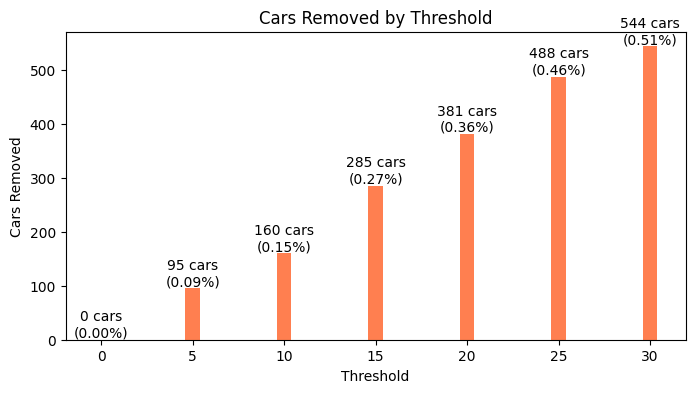

In [8]:
manufacturer_counts = df['manufacturer'].value_counts()
threshold_data = []

for threshold in [0,5, 10, 15, 20, 25, 30]:
    mask = manufacturer_counts < threshold
    
    threshold_data.append({
        'Threshold': threshold,
        'Manufacturers Removed': mask.sum(),
        'Manufacturers Kept': (~mask).sum(),
        'Cars Removed': manufacturer_counts[mask].sum(),
        'Cars Kept': manufacturer_counts[~mask].sum(),
        'Data Lost %': f'{(manufacturer_counts[mask].sum()/len(df)*100):.2f}%'
    })

threshold_df = pd.DataFrame(threshold_data)
display(threshold_df.style.hide(axis='index'))



fig, ax = plt.subplots(figsize=(8,4))
ax.bar(threshold_df['Threshold'], threshold_df['Cars Removed'], color='coral')
ax.set_xlabel('Threshold')
ax.set_ylabel('Cars Removed')
ax.set_title('Cars Removed by Threshold')

# %
for i in range(len(threshold_df)):
    ax.text(threshold_df['Threshold'][i], 
            threshold_df['Cars Removed'][i], 
            f'{threshold_df["Cars Removed"][i]} cars\n({threshold_df["Data Lost %"][i]})',  
            ha='center', va='bottom')
plt.show()

## **Year Analysis**

---

### **Year Ranges**

Range,Count,%,Avg Price (M Ft)
- 1990,1277,1.20,5.26
1990 - 2000,3248,3.05,1.86
2000 - 2005,8133,7.64,1.19
2005 - 2010,18638,17.51,1.86
2010 - 2015,22354,21.00,3.35
2015 - 2020,21777,20.46,7.03
2020 - 2025,20376,19.14,14.93
2025 -,10644,10.00,17.95


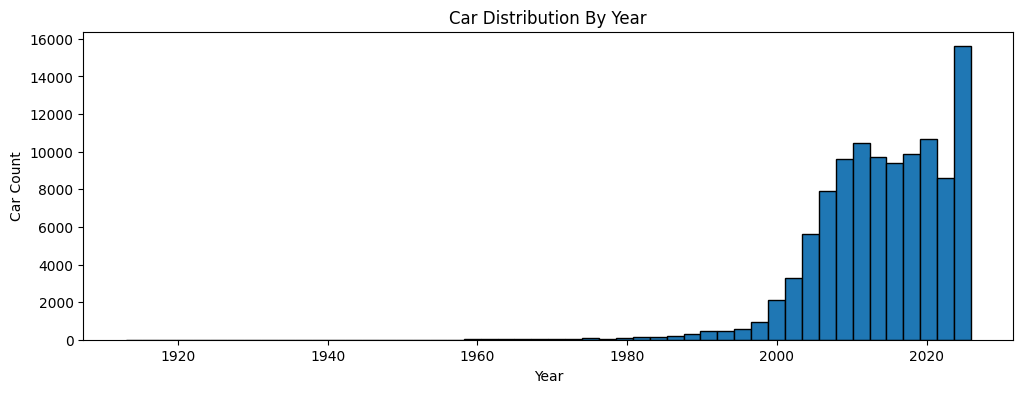

In [9]:
ranges = [
    (0, 1990, ' - 1990'),
    (1990, 2000, '1990 - 2000'),
    (2000, 2005, '2000 - 2005'),
    (2005, 2010, '2005 - 2010'),
    (2010, 2015, '2010 - 2015'),
    (2015, 2020, '2015 - 2020'),
    (2020, 2025, '2020 - 2025'),
    (2025, float('inf'), '2025 - ')
]

data = []
for low, high, label in ranges:
    mask = (df['year'] >= low) & (df['year'] < high)
    count = len(df[(df['year'] >= low) & (df['year'] < high)])
    percent = count / len(df) * 100
    avg_price = df[mask]['price'].mean()
    
    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}',
        'Avg Price (M Ft)': f'{avg_price/1e6:.2f}'
    })

year_ranges_df = pd.DataFrame(data)
display(year_ranges_df.style.hide(axis='index'))


plt.figure(figsize=(12, 4))
plt.hist(df['year'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Car Count')
plt.title('Car Distribution By Year')
plt.show()


### **Outliers & Oldest, Newest Cars**

In [10]:
oldest_df = df.sort_values('year', ascending=True).head(20)
newest_df = df.sort_values('year', ascending=False).head(20)

oldest_df = pd.DataFrame({
    'Year': oldest_df['year'].values,
    'Price': oldest_df['price'].fillna(0).astype(int).values,
    'Manufacturer': oldest_df['manufacturer'].values,
    'Model': oldest_df['model'].values,
    
    '' : ' | '
})

newest_df = pd.DataFrame({
    '' : ' | ',

    'Year': newest_df['year'].values,
    'Price': newest_df['price'].values.astype(int),
    'Manufacturer': newest_df['manufacturer'].values,
    'Model': newest_df['model'].values
})

# Combine side by side
combined = pd.concat(
    [oldest_df, newest_df],
    axis=1
)
combined['Price'] = combined['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year"]:
    combined[col] = combined[col].map(lambda x: f"{x:.2f}") 

# Display without index
pd.set_option("display.max_rows", None)
display(combined.style.hide(axis="index"))


Year,Price,Manufacturer,Model,,,Year,Price,Manufacturer,Model
1913.00,52 000 000,REPLIKA,EGYÉB,|,|,2025.92,24 320 000,MERCEDES-BENZ,C-OSZTÁLY C 220
1920.17,6 499 999,FIAT,508,|,|,2025.92,52 035 580,MERCEDES-AMG,GLE GLE 53
1925.00,10 000 000,PEUGEOT,172R,|,|,2025.92,49 644 350,MERCEDES-BENZ,EQS
1928.42,10 500 000,FORD,A MODELL,|,|,2025.92,37 018 520,MERCEDES-BENZ,EQE
1929.00,8 500 000,CHRYSLER,EGYÉB,|,|,2025.92,33 606 200,MERCEDES-BENZ,GLC-OSZTÁLY GLC 220
1929.25,0,FORD,A MODELL,|,|,2025.92,25 815 680,MERCEDES-BENZ,EQA
1931.00,5 100 000,PEUGEOT,201,|,|,2025.92,23 559 000,MERCEDES-BENZ,C-OSZTÁLY C 220
1935.00,32 000 000,ADLER,JUNIOR,|,|,2025.92,29 249 070,MERCEDES-BENZ,GLC-OSZTÁLY GLC 300
1937.00,7 499 999,FIAT,508,|,|,2025.92,22 352 710,MERCEDES-BENZ,CLA-OSZTÁLY CLA 250
1939.17,0,TATRA,57/B,|,|,2025.92,25 951 450,MERCEDES-BENZ,E-OSZTÁLY E 200


## **Kilometer Analysis**

---

### **Kilometer Ranges**



Range,Count,%,Avg Price
0 - 500,10036,9.43,17.06 M
500 - 50 000,11426,10.73,17.69 M
50 000 - 100 000,12563,11.80,9.15 M
100 000 - 200 000,35487,33.34,4.63 M
200 000 - 300 000,25099,23.58,2.89 M
300 000 - 500 000,9636,9.05,2.10 M
500 000 - 1 000 000,452,0.42,1.80 M
1 000 000 -,36,0.03,3.43 M


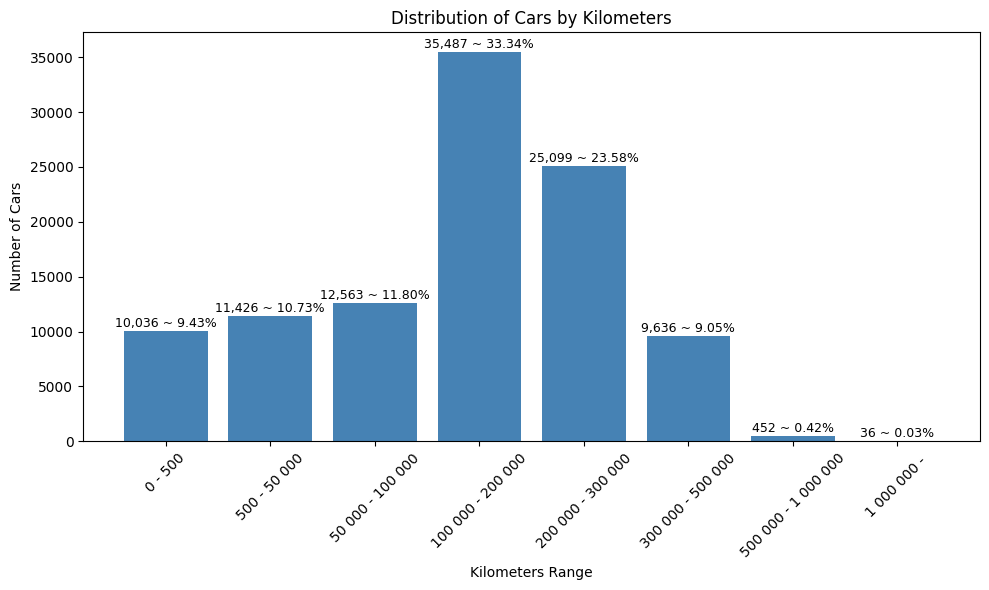

In [11]:
price_ranges = [
    (0, 500, '0 - 500'),
    (500, 50_000, '500 - 50 000'),
    (50_000, 100_000, '50 000 - 100 000'),
    (100_000, 200_000, '100 000 - 200 000'),
    (200_000, 300_000, '200 000 - 300 000'),
    (300_000, 500_000, '300 000 - 500 000'),
    (500_000, 1_000_000, '500 000 - 1 000 000'),
    (1_000_000, float('inf'), '1 000 000 - ')
]

data = []
for low, high, label in price_ranges:
    mask = (df['kilometers'] >= low) & (df['kilometers'] < high)
    count = len(df[(df['kilometers'] >= low) & (df['kilometers'] < high)])
    percent = count / len(df) * 100

    subset = df[mask]
    avg_price = subset['price'].mean()

    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}',
        'Avg Price': f'{avg_price/1e6:.2f} M'
    })

km_ranges_df = pd.DataFrame(data)
display(km_ranges_df.style.hide(axis='index'))


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(km_ranges_df['Range'], km_ranges_df['Count'], color='steelblue')
ax.set_xlabel('Kilometers Range')
ax.set_ylabel('Number of Cars')
ax.set_title('Distribution of Cars by Kilometers')
ax.tick_params(axis='x', rotation=45)

for bar, count, percent in zip(bars, km_ranges_df['Count'], km_ranges_df['%']):
   ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
           f'{count:,} ~ {percent}%',
           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### **Outliers & Possible Errors, Cars with the most Kilometers**




In [12]:
top_km_df = df.sort_values('kilometers', ascending=False).head(50)

top_km_df = pd.DataFrame({
    'Kilometers': top_km_df['kilometers'].values,
    'Price': top_km_df['price'].fillna(0).astype(int).values,
    'Year' : top_km_df['year'].values,
    'Manufacturer': top_km_df['manufacturer'].values,
    'Model': top_km_df['model'].values,
    'Kw' : top_km_df['kw']
})

for col in ["Kilometers", "Price"]:
    top_km_df[col] = top_km_df[col].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "Kw"]:
    top_km_df[col] = top_km_df[col].map(lambda x: f"{x:.2f}") 


display(top_km_df.style.hide(axis="index"))

Kilometers,Price,Year,Manufacturer,Model,Kw
16 777 215,300 000,2001.92,OPEL,CORSA CORSA C,55.00
16 777 215,1 250 000,2013.00,SEAT,LEON,132.00
16 777 215,10 480 000,2021.33,TESLA,MODEL 3,389.00
16 777 215,2 599 000,2006.00,HONDA,CR-V,103.00
12 121 212,850 000,2003.00,HONDA,HR-V,77.00
8 457 201,865 000,1987.50,SUZUKI,SJ SAMURAI,nan
5 100 000,21 990 000,2024.00,AUDI,Q4,210.00
5 000 700,660 000,2000.58,VOLKSWAGEN,PASSAT PASSAT V,85.00
4 390 099,170 000,1995.83,VOLKSWAGEN,PASSAT PASSAT III,66.00
4 160 000,570 000,1994.00,HONDA,ACCORD,110.00


## **Fuel Type Analysis**

---

### **Overview of Unique Fuel Types**

Fuel Type,Avg Price,Count
Hibrid (Dízel),18 375 059,300
Hibrid (Benzin),16 817 999,2527
Elektromos,14 187 705,6537
Hibrid,12 303 509,2599
Dízel/Gáz,6 481 250,8
Benzin,6 473 271,52245
Dízel,6 133 130,39192
LPG,3 102 590,165
CNG,2 147 968,63
Benzin/Gáz,2 143 183,267


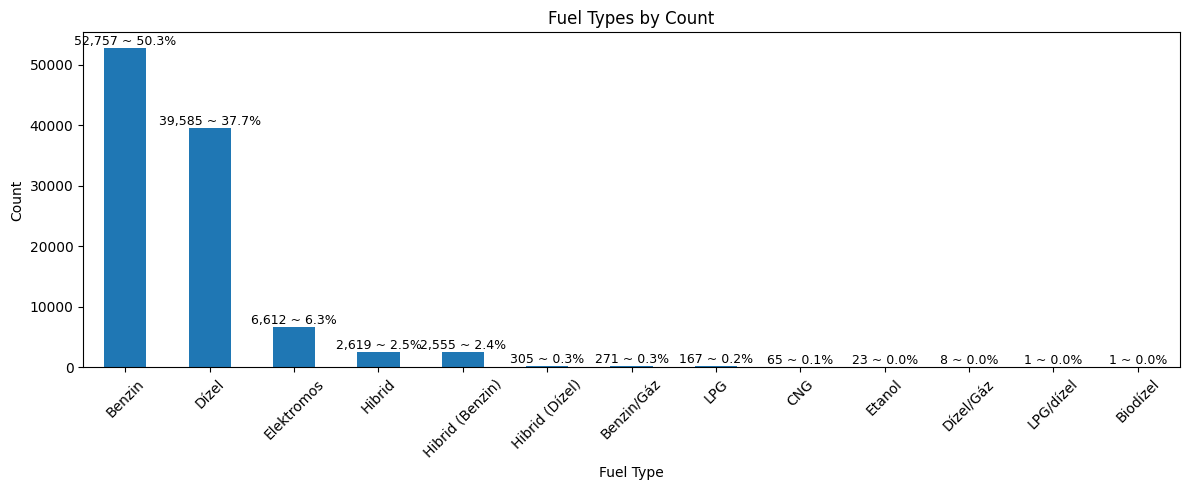

In [13]:
price_grouped = df.groupby('fuel_type')['price']
price_by_fuel = price_grouped.agg(['mean','count']).sort_values('mean', ascending=False).reset_index()
price_by_fuel = price_by_fuel.rename(columns={
    'fuel_type': 'Fuel Type',
    'mean': 'Avg Price',
    'count': 'Count'
})
price_by_fuel['Avg Price'] = price_by_fuel['Avg Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
display(price_by_fuel.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

fuel_counts = df['fuel_type'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))

bars = fuel_counts.plot(kind='bar', ax=ax)
ax.set_title('Fuel Types by Count')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


total = fuel_counts.sum()
for bar, count in zip(ax.patches, fuel_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,} ~ {count/total:.1%}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

## **Kw / LE Analysis**

---

### **Kw Ranges**

Range,Count,%,Avg Price - M
0 - 50,3538,3.32,1.260000
50 - 75,21627,20.32,2.670000
75 - 100,25814,24.25,4.010000
100 - 125,22906,21.52,6.800000
125 - 150,11414,10.72,9.030000
150 - 200,8697,8.17,11.000000
200 - 300,7100,6.67,18.040000
300 - 500,3405,3.20,31.890000
500 +,164,0.15,89.940000


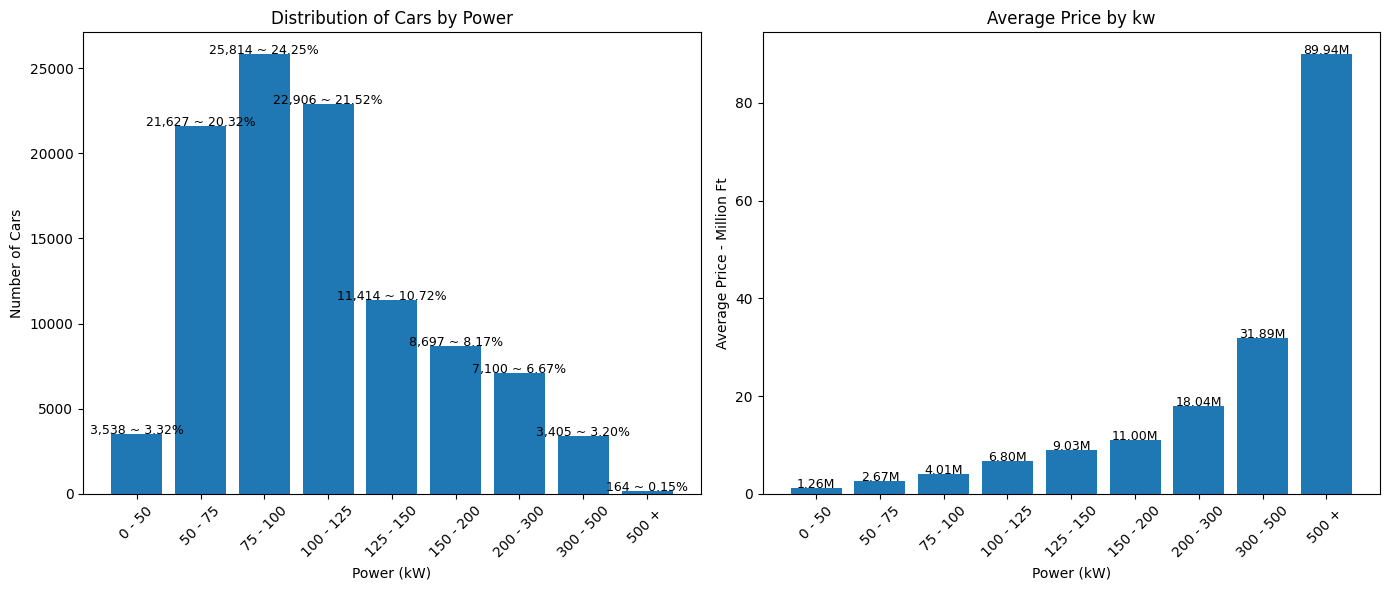

In [50]:
kw_ranges = [
   (0, 50, '0 - 50'),
   (50, 75, '50 - 75'),
   (75, 100, '75 - 100'),
   (100, 125, '100 - 125'),
   (125, 150, '125 - 150'),
   (150, 200, '150 - 200'),
   (200, 300, '200 - 300'),
   (300, 500, '300 - 500'),
   (500, float('inf'), '500 + ')
]

data = []
for low, high, label in kw_ranges:
   mask = (df['kw'] >= low) & (df['kw'] < high)
   count = mask.sum()
   percent = count / len(df) * 100
   
   subset = df[mask]
   avg_price = subset['price'].mean()
   
   data.append({
       'Range': label,
       'Count': count,
       '%': f'{percent:.2f}',
       'Avg Price - M': round(avg_price/1e6,2)
   })

kw_ranges_df = pd.DataFrame(data)
display(kw_ranges_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(kw_ranges_df['Range'], kw_ranges_df['Count'])
axes[0].set_xlabel('Power (kW)')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Power')
axes[0].tick_params(axis='x', rotation=45)

for i, row in kw_ranges_df.iterrows():
    axes[0].text(i, row['Count'], f"{row['Count']:,} ~ {row['%']}%", 
         ha='center', fontsize=9)


axes[1].bar(kw_ranges_df['Range'], kw_ranges_df['Avg Price - M'])
axes[1].set_xlabel('Power (kW)')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by kw')
axes[1].tick_params(axis='x', rotation=45)

for i, row in kw_ranges_df.iterrows():
    axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f}M", 
         ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### **Outliers & Possible Errors**

In [51]:
max_kw_df = df.sort_values('kw', ascending=False).head(30)

max_kw_df = pd.DataFrame({
    'Kw': max_kw_df['kw'].values,
    'Price': max_kw_df['price'].fillna(0).astype(int).values,
    'Year' : max_kw_df['year'].values,
    'Manufacturer': max_kw_df['manufacturer'].values,
    'Model': max_kw_df['model'].values,
})

max_kw_df['Price'] = max_kw_df['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "Kw"]:
    max_kw_df[col] = max_kw_df[col].map(lambda x: f"{x:.2f}") 


display(max_kw_df.style.hide(axis="index"))

Kw,Price,Year,Manufacturer,Model
1998.00,400 000,2007.42,MAZDA,6
964.00,71 500 000,2023.42,LUCID,AIR
750.00,37 350 000,2022.92,TESLA,MODEL S
750.00,33 299 999,2023.25,TESLA,MODEL S
750.00,36 215 436,2022.83,TESLA,MODEL S
750.00,35 000 000,2022.83,TESLA,MODEL S
750.00,32 000 000,2022.92,TESLA,MODEL X
750.00,30 500 000,2023.17,TESLA,MODEL S
750.00,31 999 999,2023.17,TESLA,MODEL S
750.00,30 999 000,2022.92,TESLA,MODEL X


## **Condition Analysis**

---

### **Unique Conditions & Average Prices**

Condition,Count,Avg Price - M
Normál,36324,4.368258
Kitűnő,30722,10.494533
Megkímélt,23928,3.931389
Újszerű,9219,14.182617
Sérülésmentes,6254,11.899477


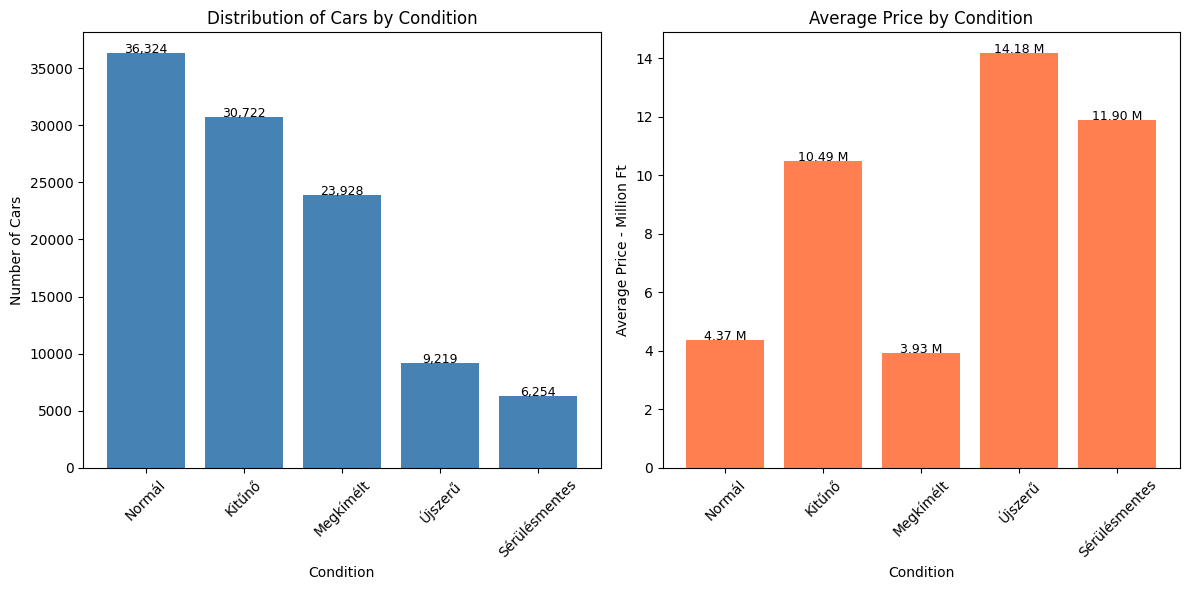

In [ ]:
condition_counts = df['condition'].value_counts()
price_by_condition = df.groupby('condition')['price'].mean()

price_condition_df = pd.DataFrame({
    'Condition': condition_counts.index,
    'Count': condition_counts.values,
    'Avg Price - M': [price_by_condition[condition]/1e6 for condition in condition_counts.index]
})

display(price_condition_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(price_condition_df['Condition'], price_condition_df['Count'], color='steelblue')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Condition')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(price_condition_df['Condition'], price_condition_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Condition')
axes[1].tick_params(axis='x', rotation=45)


for i, row in price_condition_df.iterrows():
    axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
    axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=9)



plt.tight_layout()
plt.show()

## **Body Type Analysis**

---

### **Unique Body Types & Their Average Prices**

Body Type,Count,Avg Price - M
Ferdehátú,29205,3.532063
Városi terepjáró (crossover),23506,11.435987
Kombi,19402,6.514374
Sedan,11773,7.478103
Egyterű,9979,3.086970
Coupe,4313,14.605448
Cabrio,2595,10.032808
Terepjáró,2270,15.683425
Kisbusz,1871,11.407944
Pickup,685,12.011151


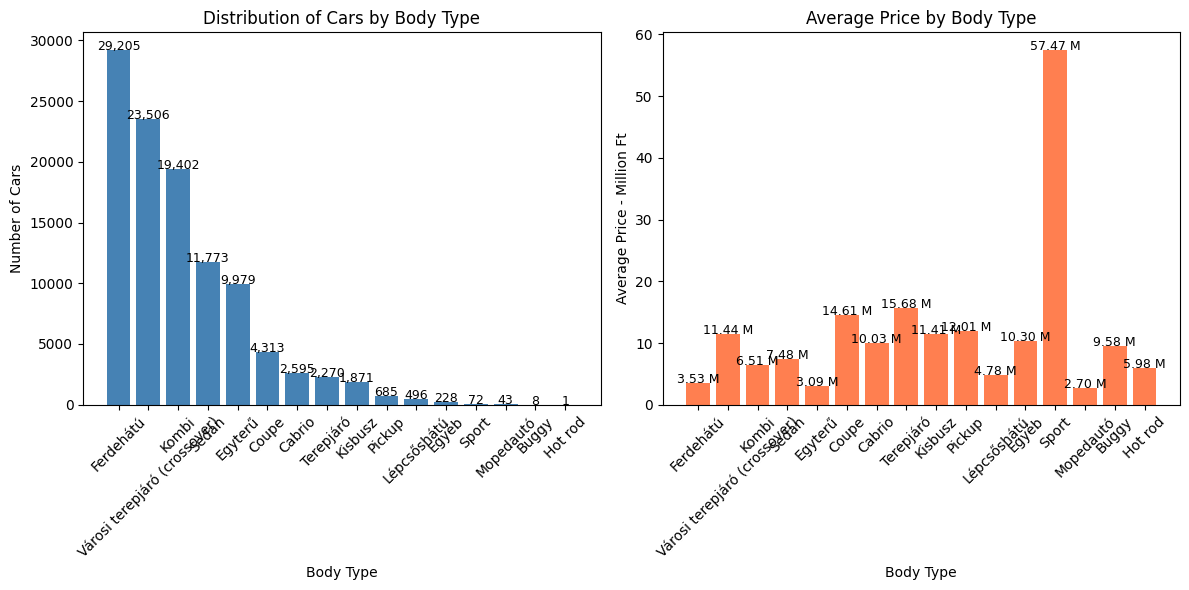

In [67]:
body_type_counts = df['body_type'].value_counts()
price_by_body_type = df.groupby('body_type')['price'].mean()

body_type_price_df = pd.DataFrame({
    'Body Type': body_type_counts.index,
    'Count': body_type_counts.values,
    'Avg Price - M': [price_by_body_type[body_type]/1e6 for body_type in body_type_counts.index]
})

display(body_type_price_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(body_type_price_df['Body Type'], body_type_price_df['Count'], color='steelblue')
axes[0].set_xlabel('Body Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Body Type')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(body_type_price_df['Body Type'], body_type_price_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Body Type')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Body Type')
axes[1].tick_params(axis='x', rotation=45)


for i, row in body_type_price_df.iterrows():
    axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
    axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=9)



plt.tight_layout()
plt.show()

## **Engine Capacity Analysis**

---

### **Possible Data Errors with Electric Cars**

In [79]:
electric_count = (df['fuel_type'] == 'Elektromos').sum()

electric_mask = df['fuel_type'] == 'Elektromos'
electric_nan = df[electric_mask & df['engine_capacity'].isna()].shape[0]
electric_not_nan = df[electric_mask & df['engine_capacity'].notna()].shape[0]

electric_analysis_df = pd.DataFrame({
   'Category': ['Electric with NaN engine capacity', 'Electric with engine capacity value', 'Total Electric Cars'],
   'Count': [electric_nan, electric_not_nan, electric_count],
})

display(electric_analysis_df.style.hide(axis='index'))

Category,Count
Electric with NaN engine capacity,6582
Electric with engine capacity value,30
Total Electric Cars,6612


### **Ranges, & Their connection with price**

Range,Count,%,Avg Price - M
Electric,8184,7.69,12.700000
1 - 500,32,0.03,5.870000
500 - 1000,4881,4.59,4.040000
1000 - 1400,22140,20.80,3.680000
1400 - 1600,23907,22.46,5.090000
1600 - 1800,4600,4.32,3.700000
1800 - 2000,23286,21.88,7.550000
2000 - 2500,6929,6.51,6.710000
2500 - 3000,8279,7.78,13.960000
3000 - 4000,2231,2.10,26.660000


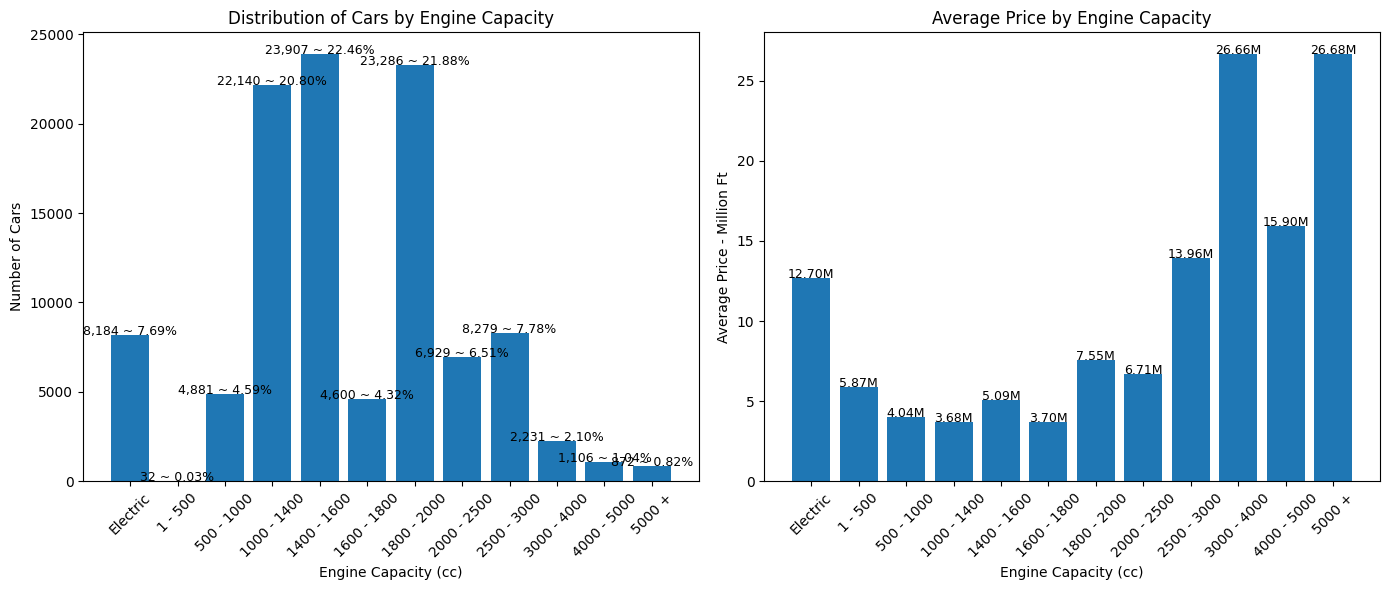

In [75]:
engine_ranges = [
   (0, 0, 'Electric'),
   (1, 500, '1 - 500'),
   (500, 1000, '500 - 1000'),
   (1000, 1400, '1000 - 1400'),
   (1400, 1600, '1400 - 1600'),
   (1600, 1800, '1600 - 1800'),
   (1800, 2000, '1800 - 2000'),
   (2000, 2500, '2000 - 2500'),
   (2500, 3000, '2500 - 3000'),
   (3000, 4000, '3000 - 4000'),
   (4000, 5000, '4000 - 5000'),
   (5000, float('inf'), '5000 +')
]

data = []
for low, high, label in engine_ranges:
   if low == 0 and high == 0:
      mask = df['engine_capacity'].isna() | (df['engine_capacity'] == 0)
   else:
      mask = (df['engine_capacity'] >= low) & (df['engine_capacity'] < high)
   
   count = mask.sum()
   percent = count / len(df) * 100
   
   subset = df[mask]
   avg_price = subset['price'].mean()
   
   data.append({
       'Range': label,
       'Count': count,
       '%': f'{percent:.2f}',
       'Avg Price - M': round(avg_price/1e6, 2)
   })

engine_ranges_df = pd.DataFrame(data)
display(engine_ranges_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(engine_ranges_df['Range'], engine_ranges_df['Count'])
axes[0].set_xlabel('Engine Capacity (cc)')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Engine Capacity')
axes[0].tick_params(axis='x', rotation=45)

for i, row in engine_ranges_df.iterrows():
   axes[0].text(i, row['Count'], f"{row['Count']:,} ~ {row['%']}%", 
        ha='center', fontsize=9)

axes[1].bar(engine_ranges_df['Range'], engine_ranges_df['Avg Price - M'])
axes[1].set_xlabel('Engine Capacity (cc)')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Engine Capacity')
axes[1].tick_params(axis='x', rotation=45)

for i, row in engine_ranges_df.iterrows():
   axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f}M", 
        ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Drive Type Analysis**

---

### **Unique Values & Their Average Prices**

Drive Type,Count,Avg Price - M
Első kerék,70500,4.723293
Összkerék,20521,14.979947
Hátsó kerék,10681,9.373078
Kapcsolható összkerék,506,8.676617
Állandó összkerék,270,13.153676


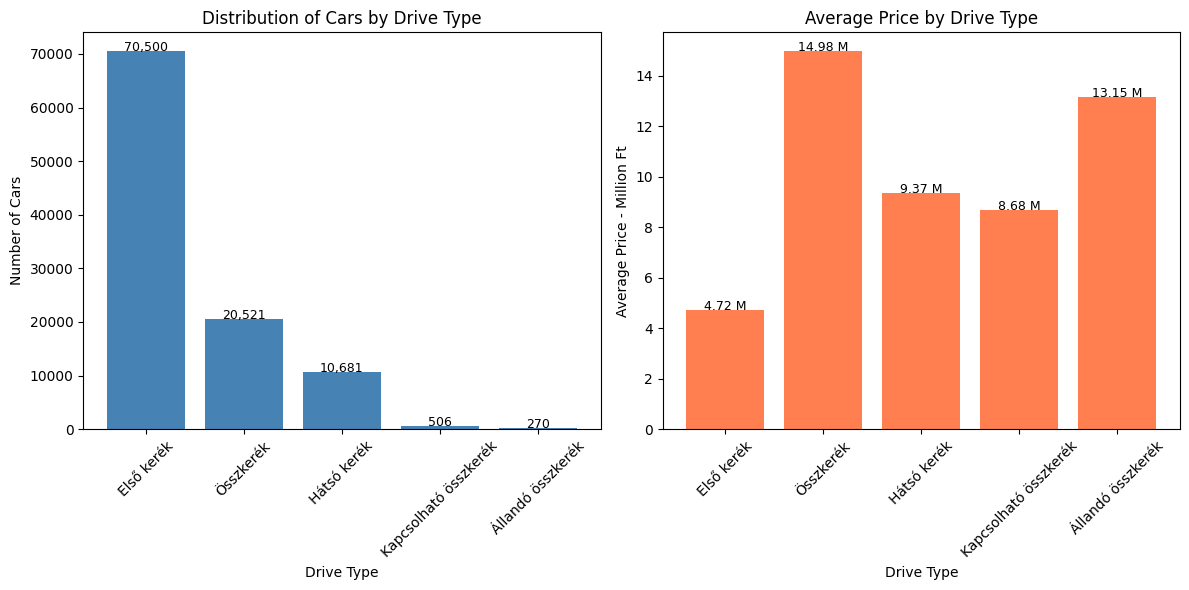

In [80]:
drive_type_counts = df['drive_type'].value_counts()
price_by_drive_type = df.groupby('drive_type')['price'].mean()

drive_type_price_df = pd.DataFrame({
   'Drive Type': drive_type_counts.index,
   'Count': drive_type_counts.values,
   'Avg Price - M': [price_by_drive_type[drive_type]/1e6 for drive_type in drive_type_counts.index]
})

display(drive_type_price_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(drive_type_price_df['Drive Type'], drive_type_price_df['Count'], color='steelblue')
axes[0].set_xlabel('Drive Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Drive Type')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(drive_type_price_df['Drive Type'], drive_type_price_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Drive Type')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Drive Type')
axes[1].tick_params(axis='x', rotation=45)

for i, row in drive_type_price_df.iterrows():
   axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
   axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Color Analysis**

---

### **Color Exploration**

Color,Count,Avg Price - M
Fehér,11743,7.041521
Fekete,9140,7.331940
Fekete (metál),8876,9.771577
Szürke (metál),5265,9.066112
Ezüst (metál),4950,5.719904
Szürke,4500,7.522943
Sötétszürke (metál),3518,8.053299
Fehér (metál),3450,12.225140
Ezüst,2994,4.459640
Kék (metál),2791,9.147086


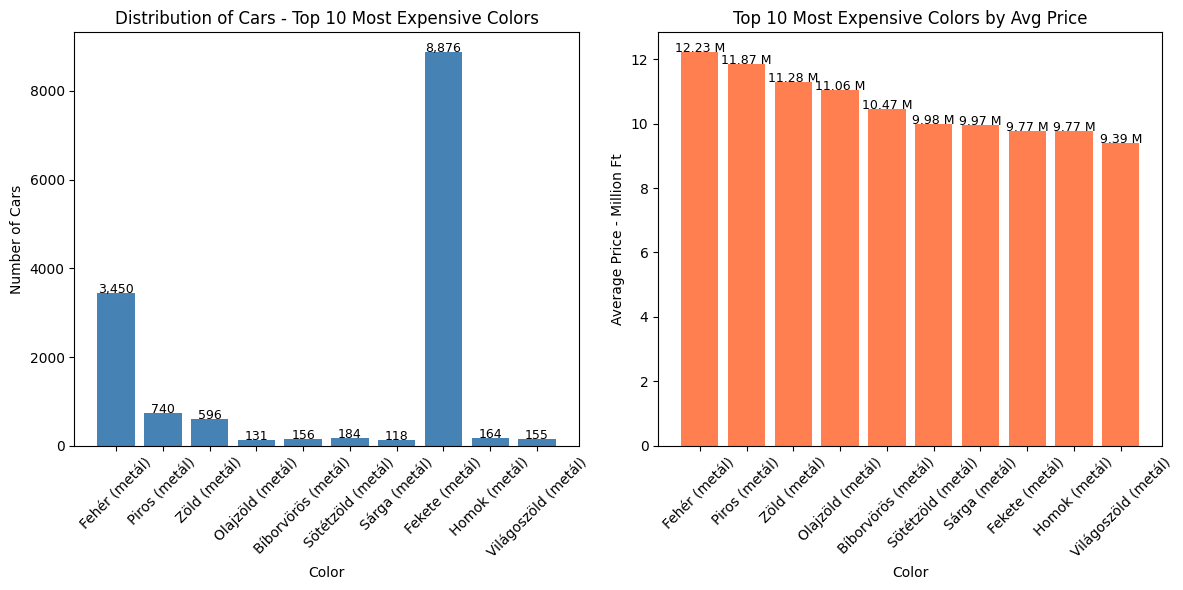

In [87]:
color_counts = df['color'].value_counts()
price_by_color = df.groupby('color')['price'].mean()

color_price_df = pd.DataFrame({
   'Color': color_counts.index,
   'Count': color_counts.values,
   'Avg Price - M': [price_by_color[color]/1e6 for color in color_counts.index]
})

display(color_price_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
filtered_colors = color_price_df[color_price_df['Count'] >= 100]
top_10_expensive = filtered_colors.nlargest(10, 'Avg Price - M')
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(top_10_expensive['Color'], top_10_expensive['Count'], color='steelblue')
axes[0].set_xlabel('Color')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars - Top 10 Most Expensive Colors')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_10_expensive['Color'], top_10_expensive['Avg Price - M'], color='coral')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Top 10 Most Expensive Colors by Avg Price')
axes[1].tick_params(axis='x', rotation=45)

for i, row in enumerate(top_10_expensive.itertuples()):
   axes[0].text(i, row.Count, f"{row.Count:,}", ha='center', fontsize=9)
   axes[1].text(i, getattr(row, '_3'), f"{getattr(row, '_3'):.2f} M", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## **Transmission Types Analysis**

---

Transmission Type,Count,Avg Price - M
Manuális,58808,3.183270
Automata,31048,12.782409
Fokozatmentes automata,10732,12.710136
Szekvenciális,725,4.611895
Tiptronic,38,25.888579
Automata felező váltóval,20,13.918999
Félautomata,17,1.243059
Manuális felező váltóval,6,3.310833
Fokozatmentes automata felező váltóval,6,4.961500


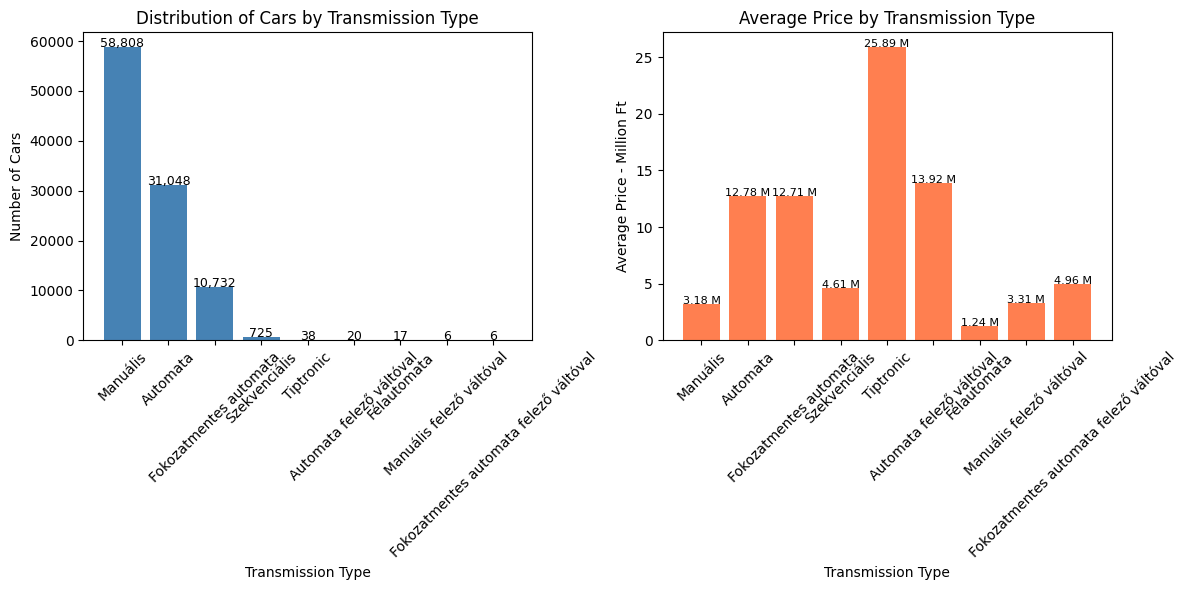

In [89]:
transmission_counts = df['transmission_type'].value_counts()
price_by_transmission = df.groupby('transmission_type')['price'].mean()

transmission_price_df = pd.DataFrame({
   'Transmission Type': transmission_counts.index,
   'Count': transmission_counts.values,
   'Avg Price - M': [price_by_transmission[transmission]/1e6 for transmission in transmission_counts.index]
})

display(transmission_price_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(transmission_price_df['Transmission Type'], transmission_price_df['Count'], color='steelblue')
axes[0].set_xlabel('Transmission Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Transmission Type')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(transmission_price_df['Transmission Type'], transmission_price_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Transmission Type')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Transmission Type')
axes[1].tick_params(axis='x', rotation=45)

for i, row in transmission_price_df.iterrows():
   axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
   axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [96]:
transmission_subtypes = df['transmission_subtype'].value_counts()

transmission_subtypes_df = pd.DataFrame({
   'Transmission Subtype': transmission_subtypes.index,
   'Count': transmission_subtypes.values,
   '%': [f'{count/len(df)*100:.2f}' for count in transmission_subtypes.values]
})

display(transmission_subtypes_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~

tiptronic_cars = df[df['transmission_subtype'] == 'tiptronic']
transmission_types = tiptronic_cars['transmission_type'].value_counts()

tiptronic_df = pd.DataFrame({
    'Transmission Type': transmission_types.index,
    'Count': transmission_types.values,
    '%': [f'{count/len(tiptronic_cars)*100:.2f}' for count in transmission_types.values]
})

display(tiptronic_df.style.hide(axis='index'))

Transmission Subtype,Count,%
tiptronic,17201,16.16


Transmission Type,Count,%
Automata,17201,100.00
